<a href="https://colab.research.google.com/github/calugj/platoon-cps/blob/main/platoon_cps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Boscolo Meneguolo Luca - 2113488

*Replay Attack Detection in a Platoon of Connected Vehicles with Cooperative Adaptive Cruise Control*

For a detailed explanation of all the results, please check the report.



# Initialization

In this block, I import the needed libraries and define the function that initializes the variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MAX_TIME = k = h = kp = kd = x = positions = prev_acc = T = Ai = bi = ci = A0 = b0 = A = b = c = None

In [2]:
def init(_MAX_TIME, _T, _k, _h):
  global MAX_TIME, k, h, kp, kd, x, positions, prev_acc, T, Ai, bi, ci, A0, b0, A, b, c

  MAX_TIME = _MAX_TIME
  k = _k
  h = _h
  T = _T

  kp = 0.2
  kd = 0.7

  positions = np.zeros((k, MAX_TIME))

  x = np.zeros((k, 3))
  prev_acc = 0

  # Initialize the matrices and vectors
  A0 = np.array([[1, 0, 0],
                [0, 1, 1],
                [0, 0, 1]])
  b0 = np.array([0, 0, 1])

  Ai = np.array([[1, -1, 0],
                [0, 1, 1],
                [(kp)/h, -(kp+kd/h), 1-(kd+1/h)]])
  bi = np.array([1, 0, kd/h])
  ci = np.array([0, 0, 1/h])

  A = np.array([[0, -1, 0],
              [0, 0, 1],
              [0, 0, 0]])
  b = np.array([1, 0, 0])
  c = np.array([0, 0, 1])

# Simulator

Platoon of $5$ cars with heading $600 ms$. This shows the functionality of the simulator.

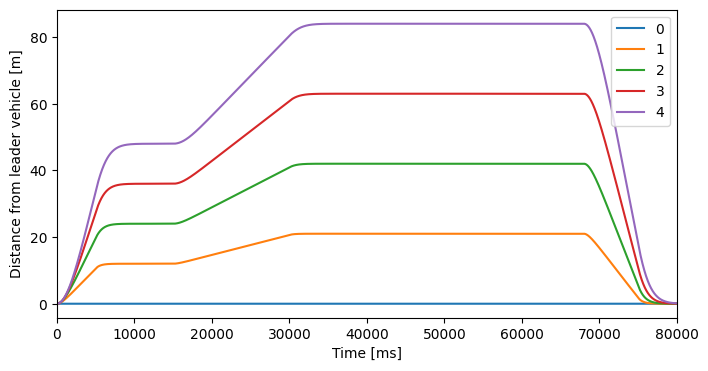

In [3]:
# Initialize the platoon. Simulation time = 45 s, resolution = 1/1000 s, cars = 5, headway = 0.6 s
init(_MAX_TIME = 80000, _T = 1/1000, _k = 5, _h = 600)

for time in range(MAX_TIME):
  if(time < 5000): ur = 4
  elif(time < 15000): ur = 0
  elif(time < 30000): ur = 1
  elif(time < 68000): ur = 0
  elif(time < 75000): ur = -5
  else: ur = 0

  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      prev_acc = ur
      x[i] = np.dot(A0, x[i]) + np.dot(b0, jerk)
    else:
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])

  for i in range(k):
    if i == 0: positions[i][time] = 0
    else: positions[i][time] = positions[i-1][time] + x[i][0]

plt.figure(figsize=(8, 4))

for i in range(k):
  plt.plot(range(MAX_TIME), positions[i], label = i)

plt.legend(loc="upper right")
plt.xlabel("Time [ms]")
plt.ylabel("Distance from leader vehicle [m]")
plt.xlim(0, 80000)
plt.show()

# Replay Attack

Platoon of $4$ cars, accelerating up to a speed of $20 m/s$, with heading $600 ms$. This shows the replay attack.

Attack starts at $time = 40000ms$

Crash at time 63501 between vehicle 3 and 2


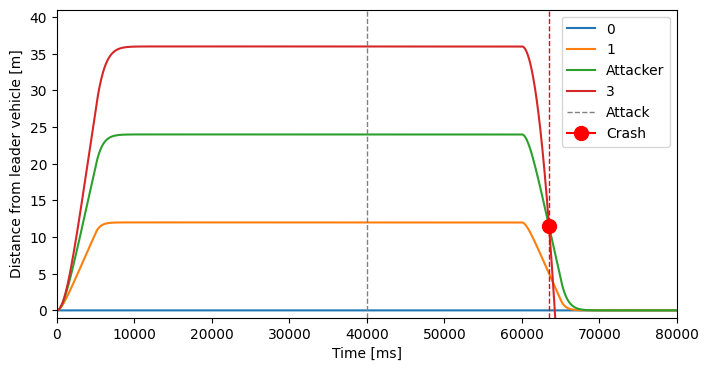

In [4]:
init(_MAX_TIME = 80000, _T = 1/1000, _k = 4, _h = 600)

# Attacker tuning
attacker = 2
attack_start = 40000
crash = False
timestamp_attack = None

# Record window tuning
RECORD_SIZE = 5000
recorded_jerks = np.zeros(RECORD_SIZE)
START_RECORDING = 20000


for time in range(MAX_TIME):
  if(time < 5000): ur = 4
  elif(time < 60000): ur = 0
  elif(time < 65000): ur = -4
  else: ur = 0

  random = np.random.normal(0, np.sqrt(0.00001))    # Add noise to the input, drawn from a Gaussian distribution with mean 0 and variance 0.00001
  ur = ur + random

  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      prev_acc = ur
      x[i] = np.dot(A0, x[i]) + np.dot(b0, jerk)
    elif i == attacker:
      if time >= START_RECORDING and time < START_RECORDING + RECORD_SIZE:
        ei = x[i][0] - h*x[i][1]
        dei = x[i-1][1] - x[i][1] - h*x[i][2]
        jerk = (x[i-1][2] - x[i][2] + (kp*ei + kd*dei)) / h
        recorded_jerks[time - START_RECORDING] = jerk
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])
    elif i != attacker+1:
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])
    elif i == attacker+1:
      if time >= attack_start:
        jerk = recorded_jerks[(time - attack_start) % RECORD_SIZE]
        dxi = np.dot(A, x[i]) + np.dot(b, x[i-1][1]) + np.dot(c, jerk)
        x[i] = x[i] + dxi
      else:
        x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])

    if (not crash and i > 0 and x[i][0] < 0):
      print("Crash at time", time, "between vehicle", i, "and", i - 1)
      timestamp_attack = time
      crash = True


  for i in range(k):
    if i == 0: positions[i][time] = 0
    else: positions[i][time] = positions[i-1][time] + x[i][0]


plt.figure(figsize=(8, 4))

for i in range(k):
  if i == attacker: label = "Attacker"
  else: label = i
  plt.plot(range(MAX_TIME), positions[i], label = label)

plt.axvline(x=attack_start, color='gray', linestyle='--', linewidth=1, label="Attack")
if crash:
  plt.axvline(x=timestamp_attack, color='red', linestyle='--', linewidth=1)
  plt.plot(timestamp_attack, positions[attacker][timestamp_attack], marker='o', color='red', markersize=10, label='Crash')
plt.legend(loc="upper right")
plt.xlabel("Time [ms]")
plt.ylabel("Distance from leader vehicle [m]")
plt.ylim(-1, np.max(positions[k-1]) + 5)
plt.xlim(0, 80000)
plt.show()

# Countermeasure - dual model detection (same as paper)

This algorithm uses the virtual model suggested by the paper.

In [5]:
init(_MAX_TIME = 1000000, _T = 1/1000, _k = 3, _h = 600)
x_virtual = np.zeros((k, 3))

# Attacker tuning
attacker = 1
attack_start = 300000
attack_end = attack_start + 150000
second_attack_start = 700000
second_attack_end = second_attack_start + 100000

# Correlation window tuning
CORRRELATE_WINDOW_SIZE = 15000
noise = [0] * (CORRRELATE_WINDOW_SIZE - 1)
obtained_jerk = [0] * (CORRRELATE_WINDOW_SIZE - 1)

# Record window tuning
RECORD_SIZE = 10000
recorded_jerks = np.zeros(RECORD_SIZE)
START_RECORDING = 100000

PLOT0 = np.zeros(int(MAX_TIME / 1000))
PLOT1 = np.zeros(int(MAX_TIME / 1000))
PLOT2 = np.zeros(int(MAX_TIME / 1000))

for time in range(MAX_TIME):
  if(time < 5000): ur = 4
  else: ur = 0

  # Add noise to the input, drawn from a Gaussian distribution with mean 0 and variance 0.00001
  random = np.random.normal(0, np.sqrt(0.00001))
  ur = ur + random
  #noise.append(random*10e3)

  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      #prev_acc = ur
      x[i] = np.dot(A0, x[i]) + np.dot(b0, jerk)
    elif i != attacker+1:
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])
    elif i == attacker+1:
      jerk = 0
      if time >= attack_start and time < attack_end or time >= second_attack_start and time < second_attack_end:
        jerk = recorded_jerks[(time - attack_start) % RECORD_SIZE]
        dxi = np.dot(A, x[i]) + np.dot(b, x[i-1][1]) + np.dot(c, jerk)
        x[i] = x[i] + dxi
      else:
        ei = x[i][0] - h*x[i][1]
        dei = x[i-1][1] - x[i][1] - h*x[i][2]
        jerk = (x[i-1][2] - x[i][2] + (kp*ei + kd*dei)) / h
        if time >= START_RECORDING and time < START_RECORDING + RECORD_SIZE:
          recorded_jerks[time - START_RECORDING] = jerk
        x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])

      noise.append(jerk*10e9)





  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      prev_acc = ur
      x_virtual[i] = np.dot(A0, x_virtual[i]) + np.dot(b0, jerk)
    elif i != attacker+1:
      x_virtual[i] = np.dot(Ai, x_virtual[i]) + np.dot(bi, x_virtual[i-1][1]) + np.dot(ci, x_virtual[i-1][2])
    elif i == attacker+1:
      ei = x_virtual[i][0] - h*x_virtual[i][1]
      dei = x_virtual[i-1][1] - x_virtual[i][1] - h*x_virtual[i][2]
      jerk = (x_virtual[i-1][2] - x_virtual[i][2] + (kp*ei + kd*dei)) / h
      x_virtual[i] = np.dot(Ai, x_virtual[i]) + np.dot(bi, x_virtual[i-1][1]) + np.dot(ci, x_virtual[i-1][2])
      obtained_jerk.append(jerk*10e9) # Acceleration of previous vehicle


  for i in range(k):
    if i == 0: positions[i][time] = 0
    else: positions[i][time] = positions[i-1][time] + x[i][0]

  if time % 1000 == 0:
    PLOT0[int(time/1000)] = np.correlate(noise, obtained_jerk, mode='valid')[0]

    noise10s = noise[4999:CORRRELATE_WINDOW_SIZE-1]
    obtained10s = obtained_jerk[4999:CORRRELATE_WINDOW_SIZE-1]

    noise5s = noise[9999:CORRRELATE_WINDOW_SIZE-1]
    obtained5s = obtained_jerk[9999:CORRRELATE_WINDOW_SIZE-1]

    PLOT1[int(time/1000)] = np.correlate(noise10s, obtained10s, mode='valid')[0]
    PLOT2[int(time/1000)] = np.correlate(noise5s, obtained5s, mode='valid')[0]


  noise.pop(0)
  obtained_jerk.pop(0)

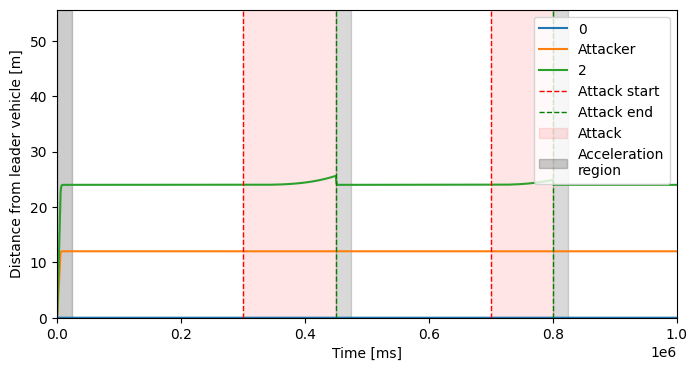

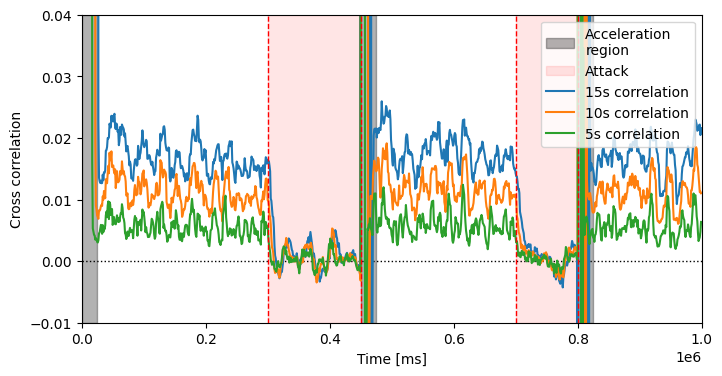

In [6]:
plt.figure(figsize=(8, 4))

for i in range(k):
  if i == attacker: label = "Attacker"
  else: label = i
  plt.plot(range(MAX_TIME), positions[i], label = label)

plt.xlabel("Time [ms]")
plt.ylabel("Distance from leader vehicle [m]")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1, label="Attack start")
plt.axvline(x=attack_end, color='green', linestyle='--', linewidth=1, label="Attack end")

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='green', linestyle='--', linewidth=1)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

plt.axvspan(0, 25000, color='black', alpha=0.2, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.15)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.15)

plt.ylim(0, np.max(positions[k-1]) + 30)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()





plt.figure(figsize=(8, 4))


plt.xlabel("Time [ms]")
plt.ylabel("Cross correlation")



plt.axvspan(0, 25000, color='black', alpha=0.3, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.3)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.3)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

#plt.axhline(y=8, color='gray', linestyle='--', linewidth=1, label="Threshold")
plt.axhline(y=0, color='black', linestyle=':', linewidth=1)


plt.plot(range(0, MAX_TIME, 1000), PLOT0, label = "15s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT1, label = "10s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT2, label = "5s correlation")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=attack_end, color='red', linestyle='--', linewidth=1)

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='red', linestyle='--', linewidth=1)

plt.ylim(-0.01, 0.04)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()

# Countermeasure - detect the attack using only the noise

Noise based detection algorithm. Shows that the attack can be detected using cross correlation. Also shows that the window size of the ccorrelation offers different performances. This detection algorithm is the simplified version of the one proposed on the paper.

In [7]:
init(_MAX_TIME = 1000000, _T = 1/1000, _k = 3, _h = 600)

# Attacker tuning
attacker = 1
attack_start = 300000
attack_end = attack_start + 150000
second_attack_start = 700000
second_attack_end = second_attack_start + 100000

# Correlation window tuning
CORRRELATE_WINDOW_SIZE = 15000
noise = [0] * (CORRRELATE_WINDOW_SIZE - 1)
obtained_jerk = [0] * (CORRRELATE_WINDOW_SIZE - 1)

# Record window tuning
RECORD_SIZE = 10000
recorded_jerks = np.zeros(RECORD_SIZE)
START_RECORDING = 100000

PLOT0 = np.zeros(int(MAX_TIME / 1000))
PLOT1 = np.zeros(int(MAX_TIME / 1000))
PLOT2 = np.zeros(int(MAX_TIME / 1000))

for time in range(MAX_TIME):
  if(time < 5000): ur = 4
  else: ur = 0

  # Add noise to the input, drawn from a Gaussian distribution with mean 0 and variance 0.00001
  random = np.random.normal(0, np.sqrt(0.00001))
  ur = ur + random
  noise.append(random*10e3)

  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      prev_acc = ur
      x[i] = np.dot(A0, x[i]) + np.dot(b0, jerk)
    elif i != attacker+1:
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])
    elif i == attacker+1:
      jerk = 0
      if time >= attack_start and time < attack_end or time >= second_attack_start and time < second_attack_end:
        jerk = recorded_jerks[(time - attack_start) % RECORD_SIZE]
        dxi = np.dot(A, x[i]) + np.dot(b, x[i-1][1]) + np.dot(c, jerk)
        x[i] = x[i] + dxi
      else:
        ei = x[i][0] - h*x[i][1]
        dei = x[i-1][1] - x[i][1] - h*x[i][2]
        jerk = (x[i-1][2] - x[i][2] + (kp*ei + kd*dei)) / h
        if time >= START_RECORDING and time < START_RECORDING + RECORD_SIZE:
          recorded_jerks[time - START_RECORDING] = jerk
        x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])

      obtained_jerk.append(jerk*10e9)


  for i in range(k):
    if i == 0: positions[i][time] = 0
    else: positions[i][time] = positions[i-1][time] + x[i][0]

  if time % 1000 == 0:
    PLOT0[int(time/1000)] = np.correlate(noise, obtained_jerk, mode='valid')[0]

    noise10s = noise[4999:CORRRELATE_WINDOW_SIZE-1]
    obtained10s = obtained_jerk[4999:CORRRELATE_WINDOW_SIZE-1]

    noise5s = noise[9999:CORRRELATE_WINDOW_SIZE-1]
    obtained5s = obtained_jerk[9999:CORRRELATE_WINDOW_SIZE-1]

    PLOT1[int(time/1000)] = np.correlate(noise10s, obtained10s, mode='valid')[0]
    PLOT2[int(time/1000)] = np.correlate(noise5s, obtained5s, mode='valid')[0]


  noise.pop(0)
  obtained_jerk.pop(0)

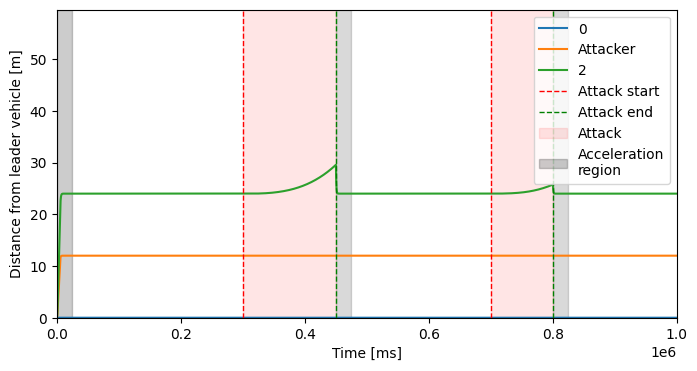

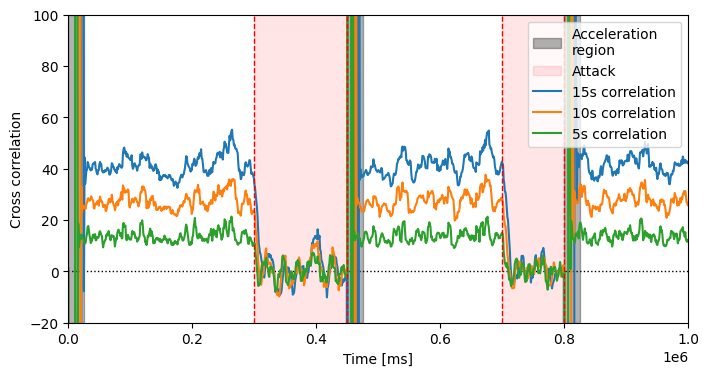

In [8]:
plt.figure(figsize=(8, 4))

for i in range(k):
  if i == attacker: label = "Attacker"
  else: label = i
  plt.plot(range(MAX_TIME), positions[i], label = label)

plt.xlabel("Time [ms]")
plt.ylabel("Distance from leader vehicle [m]")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1, label="Attack start")
plt.axvline(x=attack_end, color='green', linestyle='--', linewidth=1, label="Attack end")

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='green', linestyle='--', linewidth=1)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

plt.axvspan(0, 25000, color='black', alpha=0.2, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.15)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.15)

plt.ylim(0, np.max(positions[k-1]) + 30)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()





plt.figure(figsize=(8, 4))


plt.xlabel("Time [ms]")
plt.ylabel("Cross correlation")



plt.axvspan(0, 25000, color='black', alpha=0.3, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.3)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.3)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

#plt.axhline(y=8, color='gray', linestyle='--', linewidth=1, label="Threshold")
plt.axhline(y=0, color='black', linestyle=':', linewidth=1)


plt.plot(range(0, MAX_TIME, 1000), PLOT0, label = "15s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT1, label = "10s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT2, label = "5s correlation")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=attack_end, color='red', linestyle='--', linewidth=1)

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='red', linestyle='--', linewidth=1)

plt.ylim(-20, 100)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()

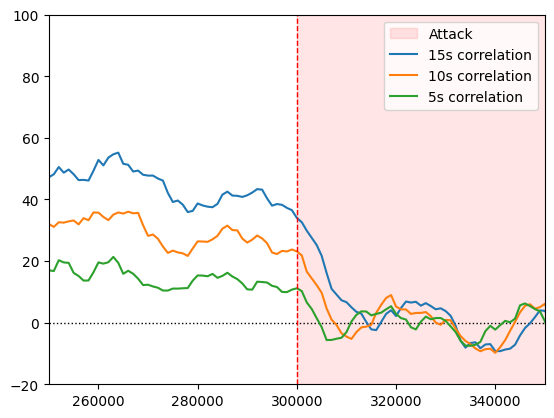

In [9]:
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.3)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.3)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

#plt.axhline(y=8, color='gray', linestyle='--', linewidth=1, label="Threshold")
plt.axhline(y=0, color='black', linestyle=':', linewidth=1)


plt.plot(range(0, MAX_TIME, 1000), PLOT0, label = "15s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT1, label = "10s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT2, label = "5s correlation")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=attack_end, color='red', linestyle='--', linewidth=1)

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='red', linestyle='--', linewidth=1)

plt.ylim(-20, 100)
plt.xlim(250000, 350000)

plt.legend(loc="upper right")
plt.show()

# Limitation of the optimization strategy

In [10]:
init(_MAX_TIME = 1000000, _T = 1/1000, _k = 20, _h = 600)

# Attacker tuning
attacker = 18
attack_start = 300000
attack_end = attack_start + 150000
second_attack_start = 700000
second_attack_end = second_attack_start + 100000

# Correlation window tuning
CORRRELATE_WINDOW_SIZE = 15000
noise = [0] * (CORRRELATE_WINDOW_SIZE - 1)
obtained_jerk = [0] * (CORRRELATE_WINDOW_SIZE - 1)

# Record window tuning
RECORD_SIZE = 10000
recorded_jerks = np.zeros(RECORD_SIZE)
START_RECORDING = 100000

PLOT0 = np.zeros(int(MAX_TIME / 1000))
PLOT1 = np.zeros(int(MAX_TIME / 1000))
PLOT2 = np.zeros(int(MAX_TIME / 1000))

for time in range(MAX_TIME):
  if(time < 5000): ur = 4
  else: ur = 0

  # Add noise to the input, drawn from a Gaussian distribution with mean 0 and variance 0.00001
  random = np.random.normal(0, np.sqrt(0.00001))
  ur = ur + random
  noise.append(random*10e3)

  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      prev_acc = ur
      x[i] = np.dot(A0, x[i]) + np.dot(b0, jerk)
    elif i != attacker+1:
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])
    elif i == attacker+1:
      jerk = 0
      if time >= attack_start and time < attack_end or time >= second_attack_start and time < second_attack_end:
        jerk = recorded_jerks[(time - attack_start) % RECORD_SIZE]
        dxi = np.dot(A, x[i]) + np.dot(b, x[i-1][1]) + np.dot(c, jerk)
        x[i] = x[i] + dxi
      else:
        ei = x[i][0] - h*x[i][1]
        dei = x[i-1][1] - x[i][1] - h*x[i][2]
        jerk = (x[i-1][2] - x[i][2] + (kp*ei + kd*dei)) / h
        if time >= START_RECORDING and time < START_RECORDING + RECORD_SIZE:
          recorded_jerks[time - START_RECORDING] = jerk
        x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])

      obtained_jerk.append(jerk*10e9)


  for i in range(k):
    if i == 0: positions[i][time] = 0
    else: positions[i][time] = positions[i-1][time] + x[i][0]

  if time % 1000 == 0:
    PLOT0[int(time/1000)] = np.correlate(noise, obtained_jerk, mode='valid')[0]

    noise10s = noise[4999:CORRRELATE_WINDOW_SIZE-1]
    obtained10s = obtained_jerk[4999:CORRRELATE_WINDOW_SIZE-1]

    noise5s = noise[9999:CORRRELATE_WINDOW_SIZE-1]
    obtained5s = obtained_jerk[9999:CORRRELATE_WINDOW_SIZE-1]

    PLOT1[int(time/1000)] = np.correlate(noise10s, obtained10s, mode='valid')[0]
    PLOT2[int(time/1000)] = np.correlate(noise5s, obtained5s, mode='valid')[0]


  noise.pop(0)
  obtained_jerk.pop(0)

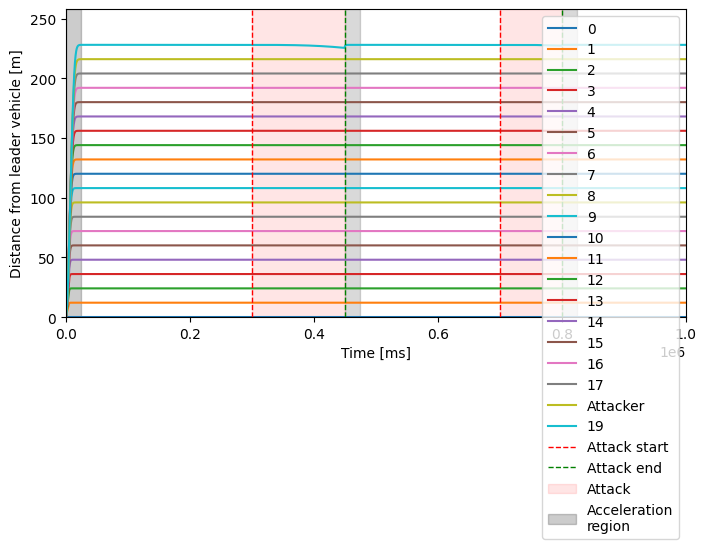

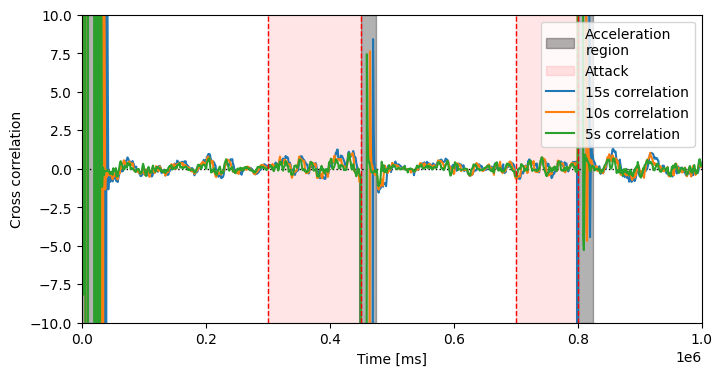

In [11]:
plt.figure(figsize=(8, 4))

for i in range(k):
  if i == attacker: label = "Attacker"
  else: label = i
  plt.plot(range(MAX_TIME), positions[i], label = label)

plt.xlabel("Time [ms]")
plt.ylabel("Distance from leader vehicle [m]")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1, label="Attack start")
plt.axvline(x=attack_end, color='green', linestyle='--', linewidth=1, label="Attack end")

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='green', linestyle='--', linewidth=1)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

plt.axvspan(0, 25000, color='black', alpha=0.2, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.15)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.15)

plt.ylim(0, np.max(positions[k-1]) + 30)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()





plt.figure(figsize=(8, 4))


plt.xlabel("Time [ms]")
plt.ylabel("Cross correlation")



plt.axvspan(0, 25000, color='black', alpha=0.3, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.3)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.3)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

#plt.axhline(y=8, color='gray', linestyle='--', linewidth=1, label="Threshold")
plt.axhline(y=0, color='black', linestyle=':', linewidth=1)


plt.plot(range(0, MAX_TIME, 1000), PLOT0, label = "15s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT1, label = "10s correlation")
plt.plot(range(0, MAX_TIME, 1000), PLOT2, label = "5s correlation")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=attack_end, color='red', linestyle='--', linewidth=1)

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='red', linestyle='--', linewidth=1)

plt.ylim(-10, 10)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()

# Countermeasure of the countermeasure - leader is adversary

The attack model showed on the paper requires the leader to be legitimate. What if the leader is also cooperating with the attacker?

In [12]:
init(_MAX_TIME = 1000000, _T = 1/1000, _k = 3, _h = 600)

# Attacker tuning
attacker = 1
attack_start = 300000
attack_end = attack_start + 150000
second_attack_start = 700000
second_attack_end = second_attack_start + 100000

# Correlation window tuning
CORRRELATE_WINDOW_SIZE = 15000
noise = [0] * (CORRRELATE_WINDOW_SIZE - 1)
obtained_jerk = [0] * (CORRRELATE_WINDOW_SIZE - 1)

# Record window tuning
RECORD_SIZE = 10000
recorded_jerks = np.zeros(RECORD_SIZE)
START_RECORDING = 100000

PLOT0 = np.zeros(int(MAX_TIME / 1000))
PLOT1 = np.zeros(int(MAX_TIME / 1000))
PLOT2 = np.zeros(int(MAX_TIME / 1000))

for time in range(MAX_TIME):
  if(time < 5000): ur = 4
  else:
    if time % 2 == 0:
      ur = 0.5
    else: ur = -0.5

  # Add noise to the input, drawn from a Gaussian distribution with mean 0 and variance 0.00001
  random = np.random.normal(0, np.sqrt(0.00001))
  ur = ur + random
  noise.append(random*10e3)

  for i in range(k):
    if(i == 0):
      jerk = (ur - prev_acc)*T*T
      prev_acc = ur
      x[i] = np.dot(A0, x[i]) + np.dot(b0, jerk)
    elif i != attacker+1:
      x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])
    elif i == attacker+1:
      jerk = 0
      if time >= attack_start and time < attack_end or time >= second_attack_start and time < second_attack_end:
        jerk = recorded_jerks[(time - attack_start) % RECORD_SIZE]
        dxi = np.dot(A, x[i]) + np.dot(b, x[i-1][1]) + np.dot(c, jerk)
        x[i] = x[i] + dxi
      else:
        ei = x[i][0] - h*x[i][1]
        dei = x[i-1][1] - x[i][1] - h*x[i][2]
        jerk = (x[i-1][2] - x[i][2] + (kp*ei + kd*dei)) / h
        if time >= START_RECORDING and time < START_RECORDING + RECORD_SIZE:
          recorded_jerks[time - START_RECORDING] = jerk
        x[i] = np.dot(Ai, x[i]) + np.dot(bi, x[i-1][1]) + np.dot(ci, x[i-1][2])

      obtained_jerk.append(jerk*10e9)


  for i in range(k):
    if i == 0: positions[i][time] = 0
    else: positions[i][time] = positions[i-1][time] + x[i][0]

  if time % 1000 == 0:
    PLOT0[int(time/1000)] = np.correlate(noise, obtained_jerk, mode='valid')[0]

    noise10s = noise[4999:CORRRELATE_WINDOW_SIZE-1]
    obtained10s = obtained_jerk[4999:CORRRELATE_WINDOW_SIZE-1]

    noise5s = noise[9999:CORRRELATE_WINDOW_SIZE-1]
    obtained5s = obtained_jerk[9999:CORRRELATE_WINDOW_SIZE-1]

    PLOT1[int(time/1000)] = np.correlate(noise10s, obtained10s, mode='valid')[0]
    PLOT2[int(time/1000)] = np.correlate(noise5s, obtained5s, mode='valid')[0]


  noise.pop(0)
  obtained_jerk.pop(0)

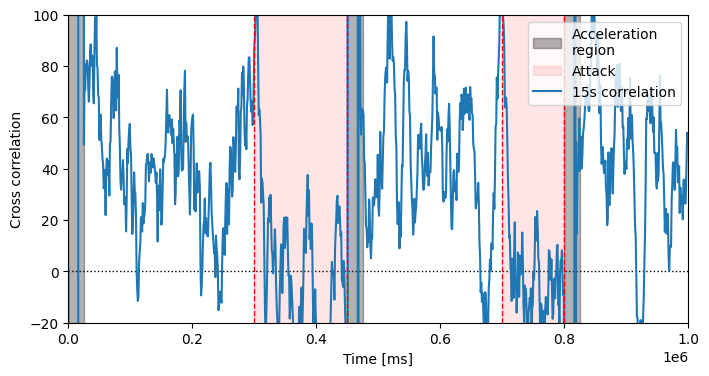

In [13]:
plt.figure(figsize=(8, 4))


plt.xlabel("Time [ms]")
plt.ylabel("Cross correlation")



plt.axvspan(0, 25000, color='black', alpha=0.3, label="Acceleration\nregion")
plt.axvspan(attack_end, attack_end+25000, color='black', alpha=0.3)
plt.axvspan(second_attack_end, second_attack_end+25000, color='black', alpha=0.3)

plt.axvspan(attack_start, attack_end, color='red', alpha=0.1, label = "Attack")
plt.axvspan(second_attack_start, second_attack_end, color='red', alpha=0.1)

#plt.axhline(y=8, color='gray', linestyle='--', linewidth=1, label="Threshold")
plt.axhline(y=0, color='black', linestyle=':', linewidth=1)


plt.plot(range(0, MAX_TIME, 1000), PLOT0, label = "15s correlation")
#plt.plot(range(0, MAX_TIME, 1000), PLOT1, label = "10s correlation")
#plt.plot(range(0, MAX_TIME, 1000), PLOT2, label = "5s correlation")

plt.axvline(x=attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=attack_end, color='red', linestyle='--', linewidth=1)

plt.axvline(x=second_attack_start, color='red', linestyle='--', linewidth=1)
plt.axvline(x=second_attack_end, color='red', linestyle='--', linewidth=1)

plt.ylim(-20, 100)
plt.xlim(0, 1000000)

plt.legend(loc="upper right")
plt.show()